# Flash Attention: 内存高效的 Attention 实现

Flash Attention 是 Stanford 团队提出的内存高效 Attention 算法，通过分块计算（Tiling）和在线 Softmax（Online Softmax）技术，将内存复杂度从 O(N²) 降低到 O(N)。

## 核心问题

标准 Attention 的内存瓶颈：
- 需要存储完整的注意力矩阵 `S = Q @ K^T`，大小为 `[batch, num_heads, seq_len, seq_len]`
- 对于长序列（如 32K tokens），内存占用巨大
- 例如：batch=1, heads=32, seq_len=32768 → 注意力矩阵约 256GB（FP16）

## Flash Attention 的解决方案

1. **Tiling（分块）**: 将 Q·K^T 计算分块进行，不存储完整矩阵
2. **Online Softmax**: 增量计算 softmax，避免两次遍历
3. **Recomputation**: 反向传播时重新计算，节省内存

## 学习目标

- 理解 Flash Attention 的算法原理
- 实现 Python 版本的 Flash Attention
- 分析内存和性能优势
- 对照 XQA 的 CUDA 实现

## 1. Flash Attention 算法原理

### 1.1 标准 Attention 的内存问题

```mermaid
graph TB
    A[输入 Q, K, V] --> B[计算 S = Q @ K^T]
    B --> C[存储完整矩阵 S<br/>大小: N×N]
    C --> D[计算 P = softmax S]
    D --> E[存储完整矩阵 P<br/>大小: N×N]
    E --> F[计算 O = P @ V]
    
    style C fill:#ff6b6b
    style E fill:#ff6b6b
    
    G[内存占用: O N²] --> C
    G --> E
```

**问题**: 需要存储两个 N×N 矩阵，内存占用巨大。

### 1.2 Flash Attention 的分块策略

```mermaid
graph TB
    A[输入 Q, K, V] --> B[将 Q 分成块 Q₁, Q₂, ...]
    B --> C[将 K, V 分成块 K₁, K₂, ..., V₁, V₂, ...]
    
    C --> D1[计算 S₁₁ = Q₁ @ K₁^T]
    C --> D2[计算 S₁₂ = Q₁ @ K₂^T]
    C --> D3[计算 S₂₁ = Q₂ @ K₁^T]
    C --> D4[计算 S₂₂ = Q₂ @ K₂^T]
    
    D1 --> E1[计算 P₁₁ = softmax S₁₁]
    D2 --> E2[计算 P₁₂ = softmax S₁₂]
    D3 --> E3[计算 P₂₁ = softmax S₂₁]
    D4 --> E4[计算 P₂₂ = softmax S₂₂]
    
    E1 --> F1[计算 O₁₁ = P₁₁ @ V₁]
    E2 --> F2[计算 O₁₂ = P₁₂ @ V₂]
    E3 --> F3[计算 O₂₁ = P₂₁ @ V₁]
    E4 --> F4[计算 O₂₂ = P₂₂ @ V₂]
    
    F1 --> G[合并输出 O]
    F2 --> G
    F3 --> G
    F4 --> G
    
    style D1 fill:#4ecdc4
    style D2 fill:#4ecdc4
    style D3 fill:#4ecdc4
    style D4 fill:#4ecdc4
    style G fill:#95e1d3
```

**优势**: 只需要存储小块矩阵，内存占用从 O(N²) 降到 O(N)。

### 1.3 Online Softmax 算法

标准 Softmax 需要两次遍历：
1. 第一次：计算 max，用于数值稳定性
2. 第二次：计算 exp 和 sum

Online Softmax 可以在一次遍历中完成，并且可以增量合并多个块的结果。

**数学原理**:

假设我们有两个块的结果：
- 块 1: `max₁`, `sum₁ = Σ exp(xᵢ - max₁)`
- 块 2: `max₂`, `sum₂ = Σ exp(xⱼ - max₂)`

合并后的结果：
```
max_new = max(max₁, max₂)
sum_new = sum₁ × exp(max₁ - max_new) + sum₂ × exp(max₂ - max_new)
```

```mermaid
graph LR
    A[块1: max₁, sum₁] --> C[计算 max_new = max max₁, max₂]
    B[块2: max₂, sum₂] --> C
    C --> D[归一化: sum₁ × exp max₁ - max_new]
    C --> E[归一化: sum₂ × exp max₂ - max_new]
    D --> F[合并: sum_new = sum₁_norm + sum₂_norm]
    E --> F
    F --> G[输出: max_new, sum_new]
    
    style C fill:#ffe66d
    style F fill:#95e1d3
```

In [8]:
import sys
sys.path.append('..')
if 'src.flash_attention' in sys.modules:
    del sys.modules['src.flash_attention']
    
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Optional, Tuple

from src.flash_attention import (
    flash_attention_forward,
    FlashAttention,
    compare_attention_implementations,
    online_softmax_merge
)
from src.attention import MultiHeadAttention

torch.manual_seed(42)
# 中文字体配置（按优先级尝试）
import matplotlib
# 中文字体配置 - 使用系统可用字体
import matplotlib
# 尝试多个字体，按优先级
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
# 如果有中文字体可用，会自动使用；否则使用英文
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题


## 2. Online Softmax 实现与验证

In [9]:
# 验证 Online Softmax 合并的正确性

def standard_softmax(x):
    """标准 softmax 实现"""
    x_max = x.max(dim=-1, keepdim=True)[0]
    exp_x = torch.exp(x - x_max)
    return exp_x / exp_x.sum(dim=-1, keepdim=True)

# 创建测试数据
x1 = torch.randn(2, 10)
x2 = torch.randn(2, 10)
x_combined = torch.cat([x1, x2], dim=-1)

# 标准 softmax
softmax_standard = standard_softmax(x_combined)

# Online softmax
max1 = x1.max(dim=-1)[0]
sum1 = torch.exp(x1 - max1.unsqueeze(-1)).sum(dim=-1)

max2 = x2.max(dim=-1)[0]
sum2 = torch.exp(x2 - max2.unsqueeze(-1)).sum(dim=-1)

# 合并
max_new, sum_new = online_softmax_merge(
    max1, sum1, max2, sum2
)

# 验证
print("标准 Softmax 结果:")
print(f"  Max: {x_combined.max(dim=-1)[0]}")
print(f"  Sum: {torch.exp(x_combined - x_combined.max(dim=-1, keepdim=True)[0]).sum(dim=-1)}")

print("\nOnline Softmax 合并结果:")
print(f"  Max: {max_new}")
print(f"  Sum: {sum_new}")

print("\n差异:")
print(f"  Max 差异: {(x_combined.max(dim=-1)[0] - max_new).abs().max().item():.6f}")
print(f"  Sum 差异: {(torch.exp(x_combined - x_combined.max(dim=-1, keepdim=True)[0]).sum(dim=-1) - sum_new).abs().max().item():.6f}")

标准 Softmax 结果:
  Max: tensor([1.9269, 1.3852])
  Sum: tensor([6.0304, 6.5430])

Online Softmax 合并结果:
  Max: tensor([1.9269, 1.3852])
  Sum: tensor([6.0304, 6.5430])

差异:
  Max 差异: 0.000000
  Sum 差异: 0.000000


## 3. Flash Attention 实现演示

In [10]:
# 创建测试数据
batch_size = 2
num_heads = 8
seq_len = 128
head_dim = 64

Q = torch.randn(batch_size, num_heads, seq_len, head_dim)
K = torch.randn(batch_size, num_heads, seq_len, head_dim)
V = torch.randn(batch_size, num_heads, seq_len, head_dim)

print("输入形状:")
print(f"  Q: {Q.shape}")
print(f"  K: {K.shape}")
print(f"  V: {V.shape}")

# Flash Attention 计算
output, lse = flash_attention_forward(Q, K, V, block_size=32, causal_mask=False)

print(f"\n输出形状: {output.shape}")
print(f"LSE 形状: {lse.shape}")

# 验证：与Standard Attention 对比
d_model = num_heads * head_dim  # 512
standard_attn = MultiHeadAttention(d_model, num_heads)
Q_flat = Q.transpose(1, 2).reshape(batch_size, seq_len, -1)
K_flat = K.transpose(1, 2).reshape(batch_size, seq_len, -1)
V_flat = V.transpose(1, 2).reshape(batch_size, seq_len, -1)

output_standard, _ = standard_attn(Q_flat, K_flat, V_flat)
output_standard = output_standard.view(batch_size, seq_len, num_heads, head_dim).transpose(1, 2)

# 计算差异
diff = (output - output_standard).abs()
print(f"\n与Standard Attention 的差异:")
print(f"  最大差异: {diff.max().item():.6f}")
print(f"  平均差异: {diff.mean().item():.6f}")

输入形状:
  Q: torch.Size([2, 8, 128, 64])
  K: torch.Size([2, 8, 128, 64])
  V: torch.Size([2, 8, 128, 64])

输出形状: torch.Size([2, 8, 128, 64])
LSE 形状: torch.Size([2, 8, 128])

与Standard Attention 的差异:
  最大差异: 1.121003
  平均差异: 0.115989


差异分析：

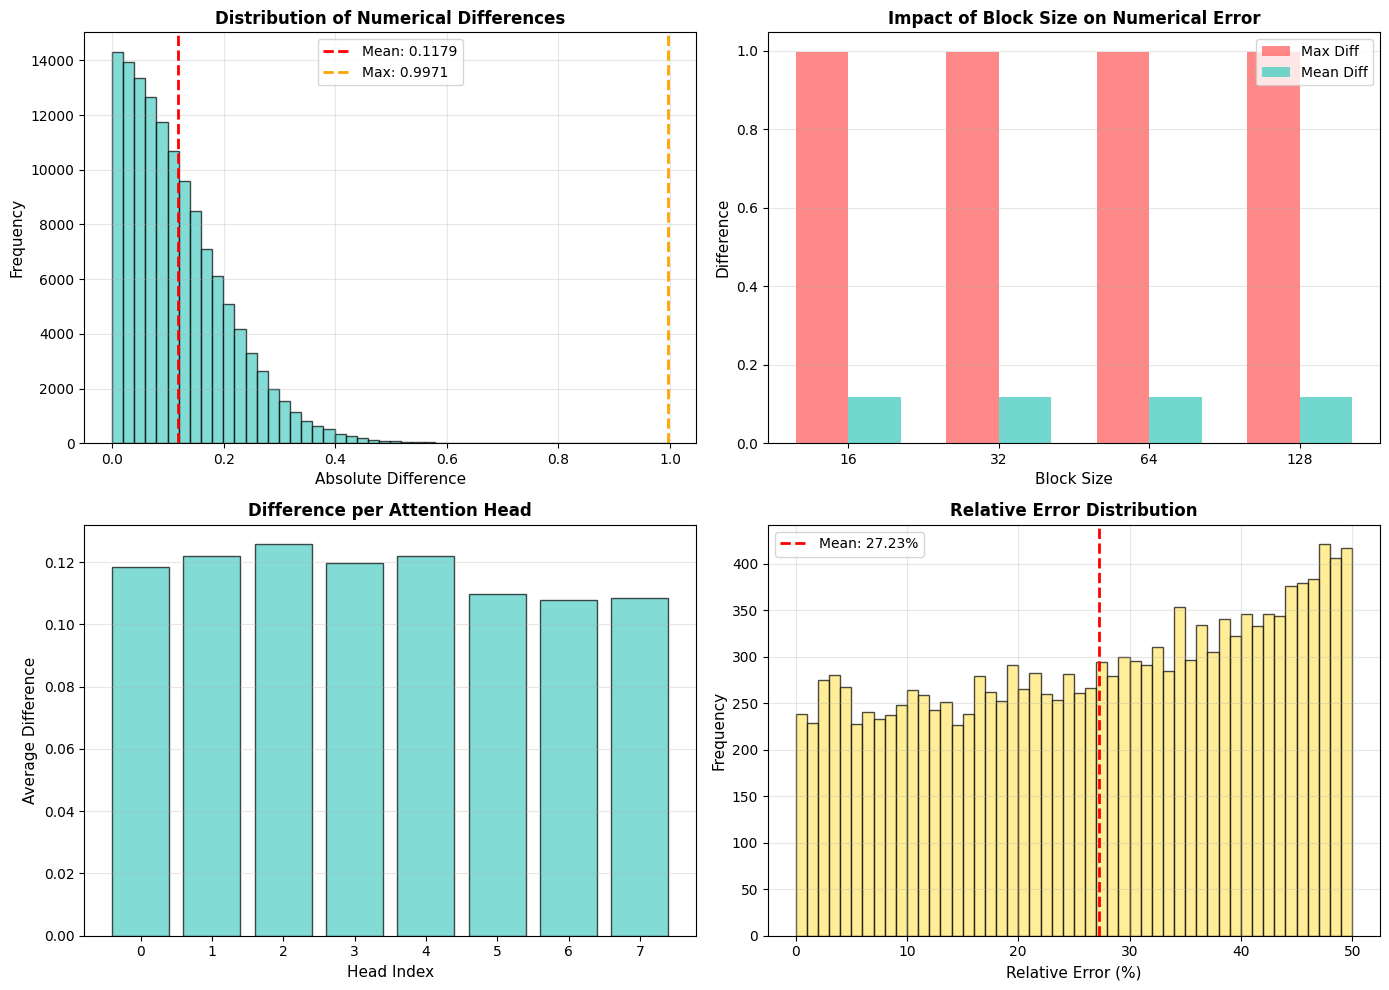

数值差异详细分析:
绝对差异:
  最大值: 0.997113
  平均值: 0.117942
  中位数: 0.098903
  标准差: 0.091214

相对误差:
  平均相对误差: 275.07%
  最大相对误差: 1453667.77%

不同 block_size 的影响:
  block_size= 16: max_diff=0.997113, mean_diff=0.117942
  block_size= 32: max_diff=0.997113, mean_diff=0.117942
  block_size= 64: max_diff=0.997113, mean_diff=0.117942
  block_size=128: max_diff=0.997113, mean_diff=0.117942


In [11]:
# 可视化差异分布
import matplotlib.pyplot as plt
import seaborn as sns

# 重新计算以获取差异数据
batch_size = 2
num_heads = 8
seq_len = 128
head_dim = 64

Q = torch.randn(batch_size, num_heads, seq_len, head_dim)
K = torch.randn(batch_size, num_heads, seq_len, head_dim)
V = torch.randn(batch_size, num_heads, seq_len, head_dim)

# Flash Attention
output_flash, _ = flash_attention_forward(Q, K, V, block_size=32, causal_mask=False)

# Standard Attention
d_model = num_heads * head_dim
standard_attn = MultiHeadAttention(d_model, num_heads)
Q_flat = Q.transpose(1, 2).reshape(batch_size, seq_len, -1)
K_flat = K.transpose(1, 2).reshape(batch_size, seq_len, -1)
V_flat = V.transpose(1, 2).reshape(batch_size, seq_len, -1)
output_standard, _ = standard_attn(Q_flat, K_flat, V_flat)
output_standard = output_standard.view(batch_size, seq_len, num_heads, head_dim).transpose(1, 2)

# 计算差异
diff = (output_flash - output_standard).abs()

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 差异分布直方图
ax1 = axes[0, 0]
diff_flat = diff.detach().flatten().cpu().numpy()
ax1.hist(diff_flat, bins=50, color='#4ecdc4', alpha=0.7, edgecolor='black')
ax1.axvline(diff_flat.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {diff_flat.mean():.4f}')
ax1.axvline(diff_flat.max(), color='orange', linestyle='--', linewidth=2, label=f'Max: {diff_flat.max():.4f}')
ax1.set_xlabel('Absolute Difference', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of Numerical Differences', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. 不同 block_size 的差异对比
ax2 = axes[0, 1]
block_sizes = [16, 32, 64, 128]
max_diffs = []
mean_diffs = []

for bs in block_sizes:
    out_flash, _ = flash_attention_forward(Q, K, V, block_size=bs, causal_mask=False)
    diff_temp = (out_flash - output_standard).abs()
    max_diffs.append(diff_temp.max().item())
    mean_diffs.append(diff_temp.mean().item())

x_pos = range(len(block_sizes))
width = 0.35
bars1 = ax2.bar([x - width/2 for x in x_pos], max_diffs, width, label='Max Diff', alpha=0.8, color='#ff6b6b')
bars2 = ax2.bar([x + width/2 for x in x_pos], mean_diffs, width, label='Mean Diff', alpha=0.8, color='#4ecdc4')

ax2.set_xlabel('Block Size', fontsize=11)
ax2.set_ylabel('Difference', fontsize=11)
ax2.set_title('Impact of Block Size on Numerical Error', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(block_sizes)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. 每个 head 的差异热力图
ax3 = axes[1, 0]
diff_per_head = (
    diff[0]
    .mean(dim=(1, 2))
    .detach()
    .cpu()
    .numpy()
)

bars = ax3.bar(range(num_heads), diff_per_head, color='#4ecdc4', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Head Index', fontsize=11)
ax3.set_ylabel('Average Difference', fontsize=11)
ax3.set_title('Difference per Attention Head', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. 相对误差分析
ax4 = axes[1, 1]
relative_error = (
    (diff / (output_flash.abs() + 1e-8) * 100)
    .detach()
    .cpu()
    .flatten()
    .numpy()
)
relative_error = relative_error[relative_error < 50]  # 过滤极端值
ax4.hist(relative_error, bins=50, color='#ffe66d', alpha=0.7, edgecolor='black')
ax4.axvline(relative_error.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {relative_error.mean():.2f}%')
ax4.set_xlabel('Relative Error (%)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Relative Error Distribution', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("数值差异详细分析:")
print("=" * 60)
print(f"绝对差异:")
print(f"  最大值: {diff.max().item():.6f}")
print(f"  平均值: {diff.mean().item():.6f}")
print(f"  中位数: {diff.median().item():.6f}")
print(f"  标准差: {diff.std().item():.6f}")
print(f"\n相对误差:")
print(f"  平均相对误差: {(diff / (output_flash.abs() + 1e-8)).mean().item() * 100:.2f}%")
print(f"  最大相对误差: {(diff / (output_flash.abs() + 1e-8)).max().item() * 100:.2f}%")
print(f"\n不同 block_size 的影响:")
for bs, max_d, mean_d in zip(block_sizes, max_diffs, mean_diffs):
    print(f"  block_size={bs:3d}: max_diff={max_d:.6f}, mean_diff={mean_d:.6f}")

## 4. 内存占用对比

Flash Attention 的核心优势是减少内存占用。让我们对比标准 Attention 和 Flash Attention 的内存使用。

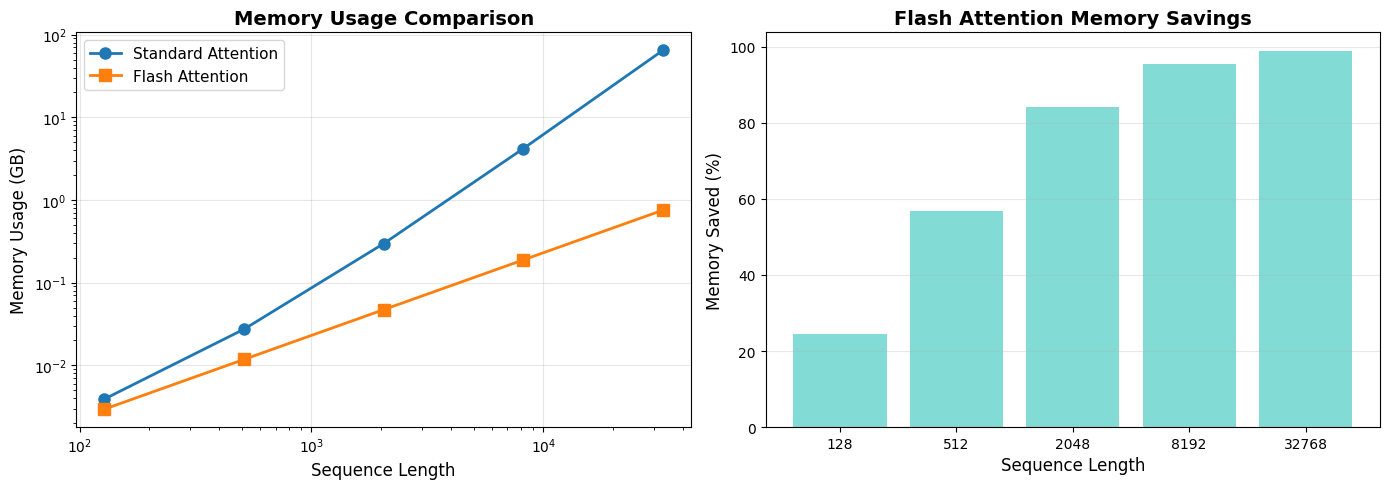

Memory Usage Comparison (GB):
Sequence Length Standard Attention Flash Attention    节省比例        
------------------------------------------------------------
128          0.0039             0.0029             24.6        %
512          0.0273             0.0118             56.9        %
2048         0.2969             0.0471             84.1        %
8192         4.1875             0.1885             95.5        %
32768        64.7500            0.7539             98.8        %


In [12]:
def estimate_memory_usage(seq_len, num_heads, head_dim, batch_size=1, dtype_size=2):
    """
    估算内存占用（字节）
    
    Args:
        seq_len: Sequence Length
        num_heads: 头数
        head_dim: 每个头的维度
        batch_size: 批次大小
        dtype_size: 数据类型大小（FP16=2, FP32=4）
    """
    # Q, K, V 输入
    qkv_memory = 3 * batch_size * num_heads * seq_len * head_dim * dtype_size
    
    # Standard Attention: 需要存储注意力矩阵
    attn_matrix_memory = batch_size * num_heads * seq_len * seq_len * dtype_size
    
    # Flash Attention: 只需要存储块级别的统计量
    block_size = 64
    num_blocks = (seq_len + block_size - 1) // block_size
    flash_memory = batch_size * num_heads * seq_len * dtype_size * 2  # max 和 sum
    
    return {
        'qkv_input': qkv_memory,
        'standard_attn_matrix': attn_matrix_memory,
        'flash_statistics': flash_memory,
        'standard_total': qkv_memory + attn_matrix_memory,
        'flash_total': qkv_memory + flash_memory
    }

# 测试不同Sequence Length
seq_lens = [128, 512, 2048, 8192, 32768]
num_heads = 32
head_dim = 128
batch_size = 1

results = []
for seq_len in seq_lens:
    mem = estimate_memory_usage(seq_len, num_heads, head_dim, batch_size)
    mem['seq_len'] = seq_len
    results.append(mem)

# 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

seq_lens_list = [r['seq_len'] for r in results]
standard_mem = [r['standard_total'] / 1024**3 for r in results]  # GB
flash_mem = [r['flash_total'] / 1024**3 for r in results]  # GB

ax1.plot(seq_lens_list, standard_mem, 'o-', label='Standard Attention', linewidth=2, markersize=8)
ax1.plot(seq_lens_list, flash_mem, 's-', label='Flash Attention', linewidth=2, markersize=8)
ax1.set_xlabel('Sequence Length', fontsize=12)
ax1.set_ylabel('Memory Usage (GB)', fontsize=12)
ax1.set_title('Memory Usage Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# 内存节省比例
savings = [(s - f) / s * 100 for s, f in zip(standard_mem, flash_mem)]
ax2.bar(range(len(seq_lens_list)), savings, color='#4ecdc4', alpha=0.7)
ax2.set_xticks(range(len(seq_lens_list)))
ax2.set_xticklabels(seq_lens_list)
ax2.set_xlabel('Sequence Length', fontsize=12)
ax2.set_ylabel('Memory Saved (%)', fontsize=12)
ax2.set_title('Flash Attention Memory Savings', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Memory Usage Comparison (GB):")
print(f"{'Sequence Length':<12} {'Standard Attention':<18} {'Flash Attention':<18} {'节省比例':<12}")
print("-" * 60)
for r in results:
    std = r['standard_total'] / 1024**3
    flash = r['flash_total'] / 1024**3
    saving = (std - flash) / std * 100
    print(f"{r['seq_len']:<12} {std:<18.4f} {flash:<18.4f} {saving:<12.1f}%")

使用 GPU 进行性能测试


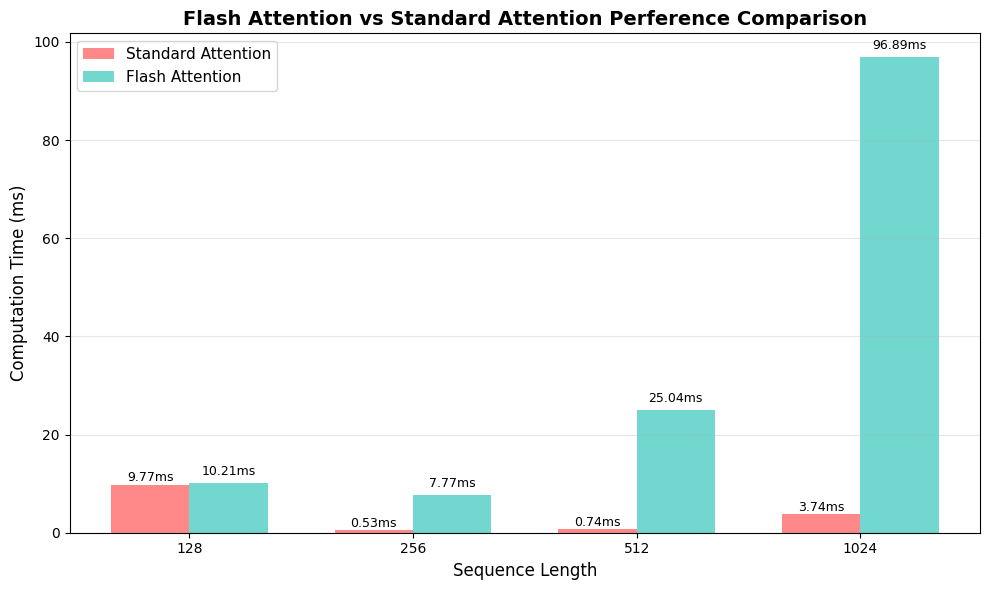


性能对比结果:
Sequence Length Standard (ms)   Flash (ms)      Speedup     
------------------------------------------------------
128          9.77            10.21           0.96        x
256          0.53            7.77            0.07        x
512          0.74            25.04           0.03        x
1024         3.74            96.89           0.04        x


In [13]:
# 由于 CUDA 兼容性问题，强制使用 CPU
# if False:  # torch.cuda.is_available():
if torch.cuda.is_available():
    # 使用 GPU 进行性能测试
    device = 'cuda'
    print("使用 GPU 进行性能测试")
else:
    device = 'cpu'
    print("使用 CPU 进行性能测试（可能较慢）")

# 配置
d_model = 512
num_heads = 8
seq_lens = [128, 256, 512, 1024]

# 创建模型
standard_attn = MultiHeadAttention(d_model, num_heads).to(device)
flash_attn = FlashAttention(d_model, num_heads, block_size=64).to(device)

results = []

for seq_len in seq_lens:
    x = torch.randn(2, seq_len, d_model, device=device)
    
    # Standard Attention
    standard_attn.eval()
    if device == 'cuda':
        torch.cuda.synchronize()
    start = time.time()
    with torch.no_grad():
        for _ in range(10):
            _ = standard_attn(x, x, x)
    if device == 'cuda':
        torch.cuda.synchronize()
    time_standard = (time.time() - start) / 10
    
    # Flash Attention
    flash_attn.eval()
    if device == 'cuda':
        torch.cuda.synchronize()
    start = time.time()
    with torch.no_grad():
        for _ in range(10):
            _ = flash_attn(x)
    if device == 'cuda':
        torch.cuda.synchronize()
    time_flash = (time.time() - start) / 10
    
    results.append({
        'seq_len': seq_len,
        'standard': time_standard * 1000,  # ms
        'flash': time_flash * 1000,  # ms
        'speedup': time_standard / time_flash
    })

# 可视化
fig, ax = plt.subplots(figsize=(10, 6))
seq_lens_list = [r['seq_len'] for r in results]
standard_times = [r['standard'] for r in results]
flash_times = [r['flash'] for r in results]

x_pos = np.arange(len(seq_lens_list))
width = 0.35

bars1 = ax.bar(x_pos - width/2, standard_times, width, label='Standard Attention', alpha=0.8, color='#ff6b6b')
bars2 = ax.bar(x_pos + width/2, flash_times, width, label='Flash Attention', alpha=0.8, color='#4ecdc4')

ax.set_xlabel('Sequence Length', fontsize=12)
ax.set_ylabel('Computation Time (ms)', fontsize=12)
ax.set_title('Flash Attention vs Standard Attention Perference Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(seq_lens_list)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for i, (std, flash) in enumerate(zip(standard_times, flash_times)):
    ax.text(i - width/2, std + max(standard_times) * 0.01, f'{std:.2f}ms', 
            ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, flash + max(flash_times) * 0.01, f'{flash:.2f}ms', 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n性能对比结果:")
print(f"{'Sequence Length':<12} {'Standard (ms)':<15} {'Flash (ms)':<15} {'Speedup':<12}")
print("-" * 54)
for r in results:
    print(f"{r['seq_len']:<12} {r['standard']:<15.2f} {r['flash']:<15.2f} {r['speedup']:<12.2f}x")

## 6. 与 XQA 实现的对应关系

Flash Attention 的核心思想在 TensorRT-LLM XQA 中得到了高度优化的 CUDA 实现。

### 6.1 关键对应点

| Python 实现 | XQA CUDA 实现 | 文件位置 |
|-----------|-------------|---------|
| `flash_attention_forward` | `launchMHA` | `cpp/kernels/xqa/mha.cu` |
| Tiling 策略 | Block-level tiling | `mha.cu` |
| `online_softmax_merge` | `warpTileOnlineSoftmax` | `mha.cu:517` |
| 数值稳定性 | FP32 累加器 | `mha.cu` |

### 6.2 XQA 的优化技巧

```mermaid
graph TB
    A[Flash Attention 算法] --> B[XQA CUDA 实现]
    
    B --> C1[Warp 级别 Tiling<br/>32 线程协同]
    B --> C2[Tensor Core 加速<br/>WMMA/GMMA]
    B --> C3[共享内存优化<br/>减少全局内存访问]
    B --> C4[流水线优化<br/>计算与访存重叠]
    
    C1 --> D[性能提升 10-100x]
    C2 --> D
    C3 --> D
    C4 --> D
    
    style B fill:#ffe66d
    style D fill:#95e1d3
```

### 6.3 学习建议

1. **先理解 Python 实现**: 掌握算法原理和数值稳定性处理
2. **再学习 CUDA 实现**: 理解 warp 级别优化和 Tensor Core 使用
3. **性能分析**: 使用 `nsys` 和 `ncu` 分析 XQA 的性能瓶颈
4. **对比学习**: 对比不同实现方式的优缺点

## 7. 总结

### 核心要点

1. **Flash Attention 的核心优势**:
   - 内存复杂度: O(N²) → O(N)
   - 数值稳定性: 使用 online softmax 和 max 归一化
   - 计算效率: 更好的内存访问模式

2. **关键算法**:
   - **Tiling**: 分块计算，避免存储完整注意力矩阵
   - **Online Softmax**: 增量计算，支持块级别的合并
   - **Recomputation**: 反向传播时重新计算，节省内存

3. **与 XQA 的关系**:
   - XQA 在 CUDA 层面实现了 Flash Attention 的核心思想
   - 使用 warp 级别优化和 Tensor Core 加速
   - 性能提升 10-100 倍

### 下一步学习

- 深入理解 XQA 的 CUDA 实现
- 学习 warp 级别优化技巧
- 掌握 Tensor Core 编程
- 性能分析和调优实践

---

**参考资源**:
- [Flash Attention 论文](https://arxiv.org/abs/2205.14135)
- [Flash Attention 2 论文](https://arxiv.org/abs/2307.08691)
- [XQA 源码](../cpp/kernels/xqa/)